In [77]:
def compute_temporal_metrics(original_values, wet_threshold=0.05):

    #values = np.asarray(values).flatten()
    #print(values)
    original_values = np.fromstring(original_values.strip('[]'), sep=' ')
    original_len = len(original_values)
    
    # Remove leading/trailing values below wet threshold
    wet = original_values > wet_threshold
    nonzero = np.flatnonzero(wet)

    if len(nonzero) == 0:
        return {'total_acc': 0,'peak_position_ratio': np.nan,'d50': np.nan,'gini': 0.0,'time_based_std': np.nan,
                'dry_ratio': np.nan,'wet_dry_transition_rate': np.nan,'max_quartile_index': np.nan}

    trimmed_values = original_values[nonzero[0]:nonzero[-1] + 1]
    n = len(trimmed_values)

    if n < original_len - 12:
        print(original_values)
        print(trimmed_values)
        print('------------')
        plt.plot(trimmed_values)
        plt.show()
    
    # Wet/dry state
    wet = trimmed_values > wet_threshold

    # --- Wet-dry transition rate ---
    if n > 1:
        transitions = np.sum(wet[1:] != wet[:-1])
        wet_dry_transition_rate = transitions / (n - 1)
    else:
        wet_dry_transition_rate = 0.0

    # --- Basic ---
    total_acc = np.nansum(trimmed_values)

    # Peak position ratio
    peak_idx = np.argmax(trimmed_values)
    peak_position_ratio = peak_idx / max(n - 1, 1)

    # --- D50 ---
    if total_acc > 0:
        cum = np.cumsum(trimmed_values) / total_acc
        time_pct = np.linspace(0, 100, n)

        idx = np.where(cum >= 0.5)[0]

        if len(idx) > 0:
            i = idx[0]

            if i == 0:
                d50 = time_pct[0]
            else:
                x1, y1 = time_pct[i-1], cum[i-1]
                x2, y2 = time_pct[i], cum[i]

                d50 = (x1 + (0.5 - y1) * (x2 - x1) / (y2 - y1)
                    if (y2 - y1) != 0 else np.nan)
        else:
            d50 = np.nan
    else:
        d50 = np.nan

    # --- Gini coefficient ---
    if n == 0 or np.all(trimmed_values == 0):
        gini = 0.0
    else:
        s = np.sort(trimmed_values)
        idx = np.arange(1, n + 1)
        gini = (2 * np.sum(idx * s) / (n * np.sum(s))) - (n + 1) / n

    # --- Time-based std ---
    if total_acc > 0:
        pos = np.linspace(0, 1, n)
        t_cg = np.sum(pos * trimmed_values) / total_acc
        time_based_std = np.sqrt(np.sum(((pos - t_cg) ** 2) * trimmed_values) / total_acc)
    else:
        time_based_std = np.nan

    # --- Event dry ratio ---
    rounded = np.round(trimmed_values, 6)
    dry_ratio = np.count_nonzero(rounded == 0) / n * 100 if n > 0 else np.nan

    # --- Quartile with most rainfall ---
    if total_acc > 0 and n > 1:
        cum = np.cumsum(trimmed_values) / total_acc
        time_norm = np.linspace(0, 1, n)

        target_pts = np.linspace(0, 1, 5)

        interp_func = interp1d(time_norm,cum,kind='linear',fill_value='extrapolate')

        resampled = interp_func(target_pts)
        fourth_with_most = int(np.argmax(np.diff(resampled)))
    else:
        fourth_with_most = np.nan

    return {'total_acc_n': total_acc,'peak_position_ratio_n': peak_position_ratio,'d50_n': d50,'gini_n': gini,
            'time_based_std_n': time_based_std,'dry_ratio_n': dry_ratio,'max_quartile_index_n': fourth_with_most,
           'length_of_active_rain': len(trimmed_values)}

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d

sys.path.insert(1, '../AnalyseResults')
from MyLovelyFunctions import *

In [68]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails_v4/all_catchments.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")

[ 0.00000414  0.00000303  0.00000534  0.00000645  0.00003428  0.18843095
  0.00000228  0.00000206  0.00000074  0.00000128  0.00000866  0.69998425
  2.6529911   0.05250481  0.07237533  0.03297272  0.08456495 25.715277
 45.490257   11.379818   21.339825   18.102608    0.36762926  0.00000096
  0.00000134  0.00000076  0.00000042  0.00000053  0.00000272  0.00000905
  0.00000163  0.00000464  0.00000215  0.00000124]
[ 0.18843095  0.00000228  0.00000206  0.00000074  0.00000128  0.00000866
  0.69998425  2.6529911   0.05250481  0.07237533  0.03297272  0.08456495
 25.715277   45.490257   11.379818   21.339825   18.102608    0.36762926]
------------


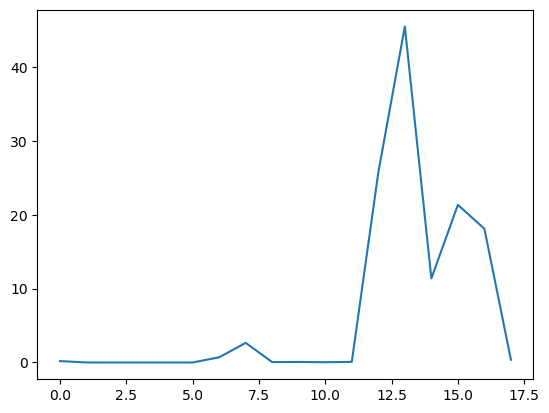

[ 0.00004353  0.03907585  0.00001679  0.00000062  0.00000522  0.00000316
  0.00000174  0.00000154  0.00000245  0.00000179  0.00016693 47.249645
 22.910984   40.059685    4.0898581   0.04392678  5.0507331   2.414202
  0.00756211  0.01426749  0.00000044  0.00000055  0.00000099  0.00000065
  0.0000003   0.00000346  0.00000157  0.00000068  0.00000031  0.00000107
  0.00000156  0.00000215  0.00000261  0.00000291  0.00000186 10.237644
  0.00927476  0.00000024  0.00000038  0.00000086  2.1391757   0.00076706
  0.00000167  0.00000215  0.0000029   0.00000221  0.00027527  0.14230166
  0.00000204  0.00000248  0.00000146  0.00000182  0.00000452  0.00000455
  0.00000086  0.00000077]
[47.249645   22.910984   40.059685    4.0898581   0.04392678  5.0507331
  2.414202    0.00756211  0.01426749  0.00000044  0.00000055  0.00000099
  0.00000065  0.0000003   0.00000346  0.00000157  0.00000068  0.00000031
  0.00000107  0.00000156  0.00000215  0.00000261  0.00000291  0.00000186
 10.237644    0.00927476  0.0000

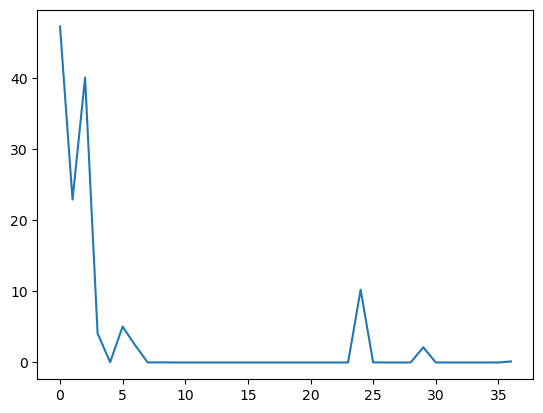

[ 0.00000102  0.00000137  0.00339507  0.1385576   2.625901    0.00003602
  0.00001241  0.00000883  0.00000068  0.00000029  0.00000036  0.33713734
  0.83713633  2.1263809   0.51610422  0.00065942  0.00000053  0.00000115
  0.00000156  0.0000006   0.00000038  0.00000044  1.8704309  31.457493
  8.4360781   1.0276183   0.0002424   0.00000019  0.00000016  0.00007037
  0.00000003  0.00000015  0.00000099  0.00000592  0.00000123  0.00000072]
[ 0.1385576   2.625901    0.00003602  0.00001241  0.00000883  0.00000068
  0.00000029  0.00000036  0.33713734  0.83713633  2.1263809   0.51610422
  0.00065942  0.00000053  0.00000115  0.00000156  0.0000006   0.00000038
  0.00000044  1.8704309  31.457493    8.4360781   1.0276183 ]
------------


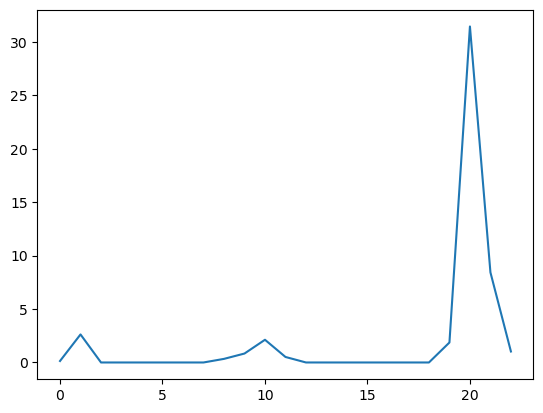

[ 0.00229282  0.00000016 26.192759   36.691059    3.1087797   1.2679147
  0.80002701  0.07376321  0.00000399  0.00000141  0.67982459  0.00000069
  0.00000046  0.00000157  0.00000103  0.00000059  0.00000116  0.00000019
  0.00000015  0.00000027  0.00000027  0.        ]
[26.192759   36.691059    3.1087797   1.2679147   0.80002701  0.07376321
  0.00000399  0.00000141  0.67982459]
------------


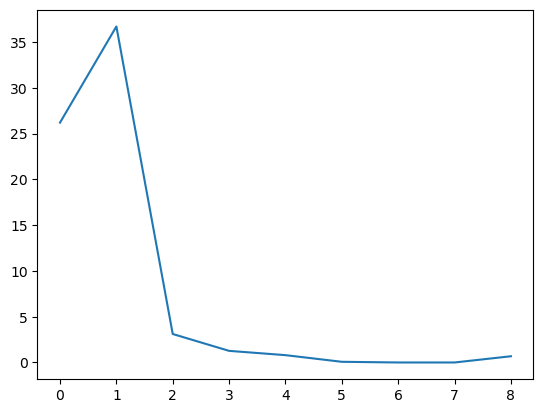

[ 0.00996666  0.2352145   0.00206418  0.00000223  0.00000077  0.00000032
  0.00000096  0.18413363 33.1521     12.899954    1.3251592   0.12995729
  0.00001356  0.00000075  0.00000268  0.00000511  0.0002091   0.00033374
  0.00002591  0.00035072  0.00026239  0.00060659  0.00003625  0.00001251]
[ 0.2352145   0.00206418  0.00000223  0.00000077  0.00000032  0.00000096
  0.18413363 33.1521     12.899954    1.3251592   0.12995729]
------------


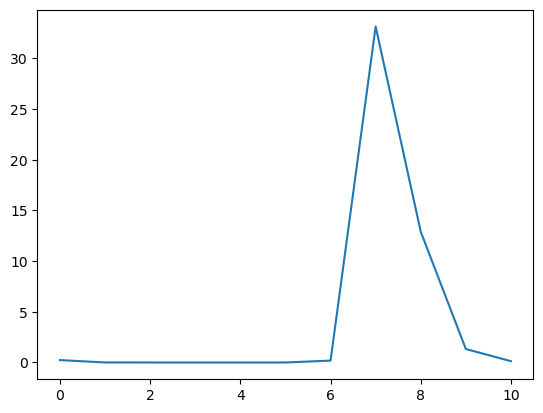

[ 0.          0.00000641  0.00000053  0.0000001   0.00000453  0.00000197
  0.00000166  0.00000306  0.00247194  0.00000091  0.14212033  0.00000463
  0.00316279  0.05711507  0.56008792  0.11011789  0.07008816  0.91002089
  1.01929414  0.17399868  0.00503689  0.2404218   1.38886321  0.09081828
  0.00011904  0.75753933  1.40364897  0.00000078  0.03928125  0.00000062
  0.00000018  0.00000153  0.13042685 33.2995453  30.5390873  11.6934185
  0.00000114  0.02073574  0.01140126  0.00000247  0.00000142  0.00000241
  0.00000189  0.00000101]
[ 0.14212033  0.00000463  0.00316279  0.05711507  0.56008792  0.11011789
  0.07008816  0.91002089  1.01929414  0.17399868  0.00503689  0.2404218
  1.38886321  0.09081828  0.00011904  0.75753933  1.40364897  0.00000078
  0.03928125  0.00000062  0.00000018  0.00000153  0.13042685 33.2995453
 30.5390873  11.6934185 ]
------------


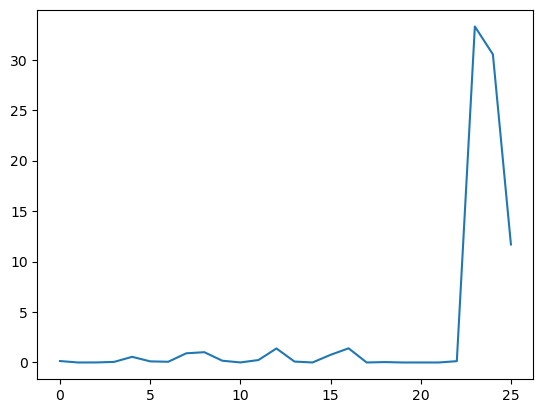

[ 0.00000499  0.66901064 11.144931    5.184083    8.7119703   1.8940676
  0.00003468  0.00027038  0.00000176 48.94651     2.4071999   0.0000324
  0.00000062  0.00000115  0.00000105  0.00000239  0.00000023  0.00000171
  0.00000108  0.00000083  0.00000073  0.00000049  0.00000177  0.
  0.          0.          0.        ]
[ 0.66901064 11.144931    5.184083    8.7119703   1.8940676   0.00003468
  0.00027038  0.00000176 48.94651     2.4071999 ]
------------


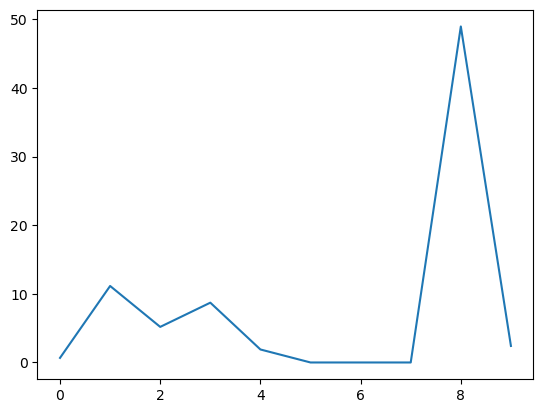

[ 0.03185677  0.02257892  0.90177161  1.0601614   4.8117409   6.5560145
  3.5952711   0.00914562  0.00069776  0.03162535  0.00006433  0.01418194
 34.066154    0.00053954  0.02727176  0.00000049  0.00000102  0.00000229
  0.00000368  0.00000053  0.0000015   0.00000143  0.00000198  0.00034031
  0.00000051  0.00000351  0.00000396  0.00001046]
[ 0.90177161  1.0601614   4.8117409   6.5560145   3.5952711   0.00914562
  0.00069776  0.03162535  0.00006433  0.01418194 34.066154  ]
------------


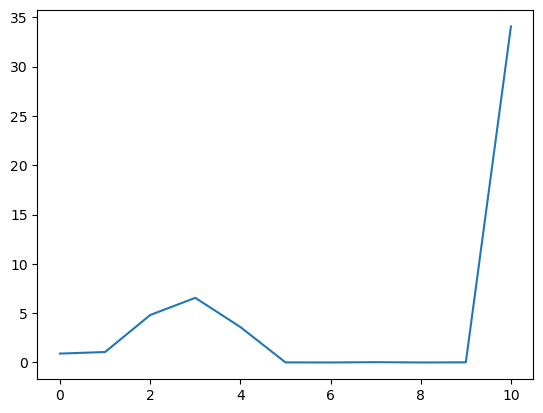

[ 0.0000018   0.00000139  0.00000034  0.00004671  0.68264902  0.0000661
  0.41069871  0.00036126  0.20671998  0.000003    0.09853655  2.3982697
 43.898281    0.87087476  0.01076538  0.00000153  0.00000103  0.00000235
  0.00002721  0.00060003  0.00002768  0.00000224  0.00000253  0.00000156]
[ 0.68264902  0.0000661   0.41069871  0.00036126  0.20671998  0.000003
  0.09853655  2.3982697  43.898281    0.87087476]
------------


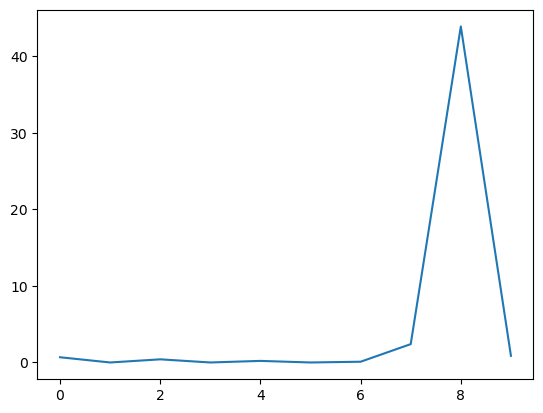

[ 0.00000013  0.0000012   0.00000011  0.00000046  0.00000215  0.00000074
  0.39096358  0.00000055  0.00000135  0.00000186  0.11748559  0.00008414
  0.83009142  0.70293671  0.5066911   0.19835162  1.1741059   0.04249097
  0.29145294  0.12561972  0.05287559  0.01824783  0.00000087 10.828822
 41.200897    5.1537447   0.0000005   0.00000069  0.00000037  0.00000015
  0.00000034  0.00001478  0.00002417  0.00000033  0.00000501  0.00000299
  0.00000059]
[ 0.39096358  0.00000055  0.00000135  0.00000186  0.11748559  0.00008414
  0.83009142  0.70293671  0.5066911   0.19835162  1.1741059   0.04249097
  0.29145294  0.12561972  0.05287559  0.01824783  0.00000087 10.828822
 41.200897    5.1537447 ]
------------


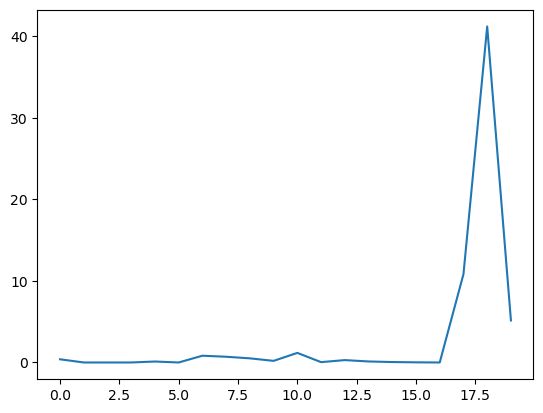

[ 0.00000111  0.00241588  4.1439776  37.630249    6.9090199   0.00006513
  0.00000119  0.00000131  0.00000025  0.00000161  0.00000061  0.00000114
  0.24810475  0.00002262  0.00000047  0.00000385  0.00002465  0.00016454
  0.01314949  0.00233012  0.00007921  0.00004367  0.00000789  0.00000304]
[ 4.1439776  37.630249    6.9090199   0.00006513  0.00000119  0.00000131
  0.00000025  0.00000161  0.00000061  0.00000114  0.24810475]
------------


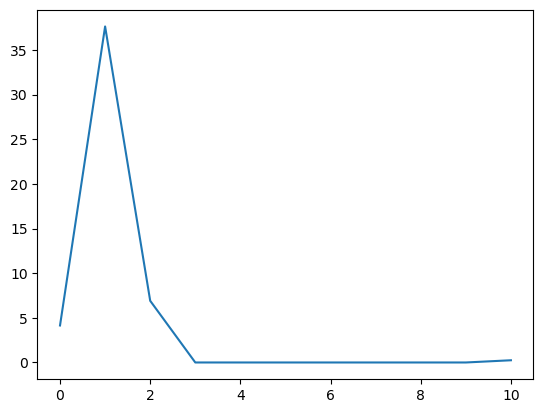

[ 0.00000105  0.1640099   0.2534152   0.00006047  1.7304566   7.2993884
  3.2662523  32.586994    2.6770639   0.00000095  0.00000116  0.00000293
  0.00000011  0.00000029  0.00000143  0.38212317  0.00000188  0.00000214
  0.00000538  0.00000811  0.00000523  0.00000564  0.00000604  0.00000608
  0.00000399  0.00000393  0.00000036  0.00000235  0.00000232  0.00000012]
[ 0.1640099   0.2534152   0.00006047  1.7304566   7.2993884   3.2662523
 32.586994    2.6770639   0.00000095  0.00000116  0.00000293  0.00000011
  0.00000029  0.00000143  0.38212317]
------------


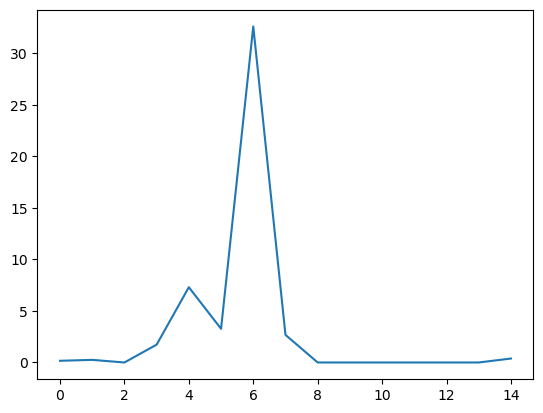

[ 0.00000232  0.00000308  0.00000069  0.00000081  0.00000187  0.00000151
  0.00000262  0.91765809  0.02132911  0.00000469  0.00000119  0.00000364
  0.0000025   0.00000222  0.00000258  0.00011054  0.01468684  0.03737418
  0.0000035   0.00000363  2.1494968   0.00000443  0.00000522  0.1151367
 22.401321   32.263962    0.00000065  0.00000067  0.82076377  0.03777574
  0.71333259  0.00000186  0.00000111  0.00000304  0.00000252  0.00000757
  0.00000068  0.00000619  0.00000331  0.00000847  0.0000006   0.00000234
  0.00000388  0.00000226]
[ 0.91765809  0.02132911  0.00000469  0.00000119  0.00000364  0.0000025
  0.00000222  0.00000258  0.00011054  0.01468684  0.03737418  0.0000035
  0.00000363  2.1494968   0.00000443  0.00000522  0.1151367  22.401321
 32.263962    0.00000065  0.00000067  0.82076377  0.03777574  0.71333259]
------------


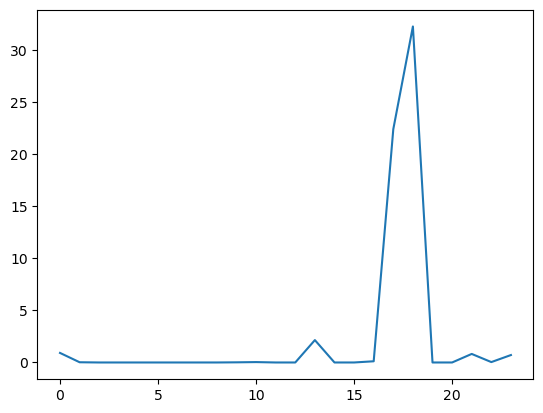

[ 0.00000098  0.00000242  0.00000215  0.00000171  0.00000156  0.00000134
  0.00000024  0.00000103  0.00000164  2.89876842  1.20673192  0.00000044
  0.0000015   0.00000118  4.90074587  8.35599136  3.21342158  0.0006653
  0.00000232  0.00000291  0.00000088  0.0000006   0.00000033  0.00000047
  0.00000122  0.00000079  0.00000168  0.00000291  0.00000088  0.00000245
  0.00000201  0.00000837  0.00015437 32.7441216  14.5041866   2.05579853
  0.00811278  0.881769    0.38717723  0.00197074  0.00000043  0.00000004
  0.0000011   0.00000486  0.00000146  0.00000108  0.00000122  0.00000408
  0.00001107  0.00000809  0.00000345  0.00000113  0.00000122  0.00000352
  0.00000879  0.00399903  0.00000318  0.00000151  0.00000372  0.00000256
  0.00000408  0.00000523]
[ 2.89876842  1.20673192  0.00000044  0.0000015   0.00000118  4.90074587
  8.35599136  3.21342158  0.0006653   0.00000232  0.00000291  0.00000088
  0.0000006   0.00000033  0.00000047  0.00000122  0.00000079  0.00000168
  0.00000291  0.00000088  

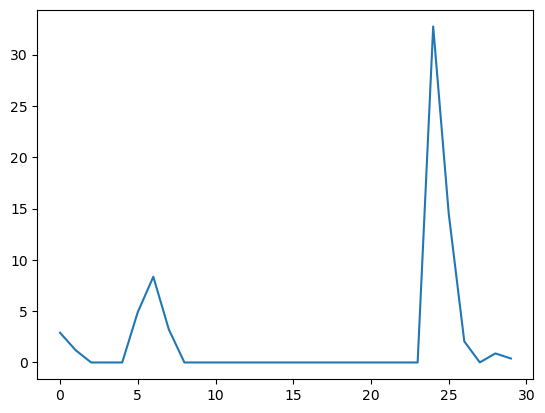

[ 0.00000326  0.00000386  1.0961787   0.00001166  0.00000269  0.00000063
  0.00000133  0.00000078  0.00000059  0.00000128  0.00000138  0.00000127
  0.00000196  0.00000084  0.00000031  0.00000047  0.00000199  0.0000023
  0.00000252  0.00000162  0.00000232  0.04791861  0.72831655  1.0840908
  6.8125877   3.2354519   0.00127317  0.00000068  0.00471974  1.4790609
  0.00637286  0.00001257  0.04397474  3.6311419   0.07352101  0.73607922
 16.684671   29.841965   37.907494   13.626696    1.9719958   7.1368113
  0.03723849  0.15705827  0.00081716  0.00000427  0.43327537  0.00318131
  0.00000096  0.00000211  0.00000224  0.00000127  0.00000116  0.00000105
  0.00000171  0.00000243  0.00000133  0.0000017   0.00000017  0.00000004]
[ 1.0961787   0.00001166  0.00000269  0.00000063  0.00000133  0.00000078
  0.00000059  0.00000128  0.00000138  0.00000127  0.00000196  0.00000084
  0.00000031  0.00000047  0.00000199  0.0000023   0.00000252  0.00000162
  0.00000232  0.04791861  0.72831655  1.0840908   6.81

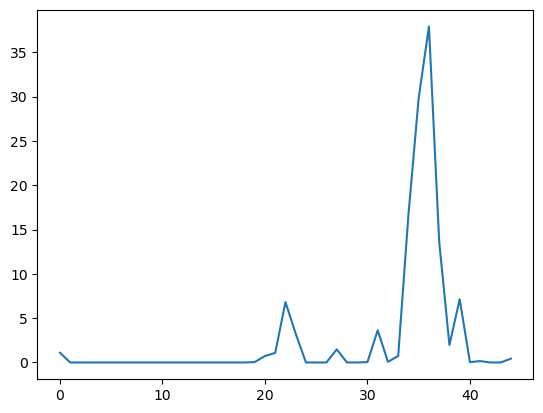

[ 0.00000774  0.00000896  0.00000182  0.00000175  0.0000029   0.00015005
  0.00000304  0.00029213  1.4210973   0.22955894  0.03502235  0.00491129
  0.00001187  0.00000173  0.0000021   0.00001281  2.3346231   0.00000273
  0.00000196  0.00000224  0.01436918  0.00275049  0.00000393  0.00000242
  0.00000512  0.00000418  0.00113918  0.00674391  0.07185809 25.653553
  1.3747585  10.598374   46.970142    0.54970914  0.00000116  0.00000336
  0.0000022   0.0000016   0.00000149  0.00000045  0.00000171  0.00000245
  0.00000118  0.00000021  0.00000071  0.00000038  0.00000017]
[ 1.4210973   0.22955894  0.03502235  0.00491129  0.00001187  0.00000173
  0.0000021   0.00001281  2.3346231   0.00000273  0.00000196  0.00000224
  0.01436918  0.00275049  0.00000393  0.00000242  0.00000512  0.00000418
  0.00113918  0.00674391  0.07185809 25.653553    1.3747585  10.598374
 46.970142    0.54970914]
------------


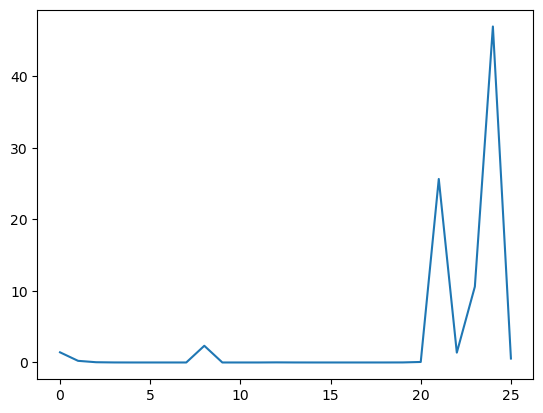

[ 0.00000029  0.00389442  0.45370811  0.00000174  0.05223677  0.00000031
  0.00000196  0.00000182  1.0891151  30.611692    0.73476577  0.00002956
  0.00001181  0.00000215  0.00000021  0.00000087  0.00001958  0.00003558
  0.0000003   0.00000295  0.00000058  0.00000021]
[ 0.45370811  0.00000174  0.05223677  0.00000031  0.00000196  0.00000182
  1.0891151  30.611692    0.73476577]
------------


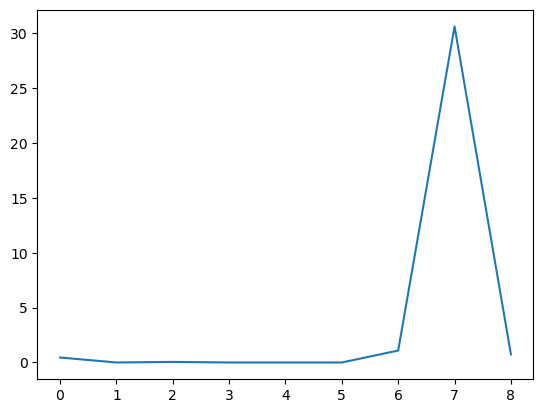

[ 0.01054938  0.00817745  0.00000088  0.0000024   0.51372385  0.00000225
  0.01878581  5.5965266   0.14866777  0.00561937  0.00043116  0.03120486
  0.0000029   0.0000015   0.00000114  0.00000102  0.00000129  0.00000595
  0.01947352 16.737692    8.4894075   0.00810638  0.02493025  0.20479834
  0.00000117  0.00000152  0.00000051  0.00000203  0.0000013   0.00000064
  0.00000059  0.00000063  0.00000113  0.00000171  0.00000154  0.00000076
  0.00000083  0.00000034  0.000001    0.00000078  0.00000147  1.3054132
 24.42564    25.64538     0.33147943  0.27578026  0.00000618  0.01733195
  0.0000027   0.00000249  0.01188074 12.436986   63.858959   46.756775
  0.62187749  0.08684549  0.00002831  0.00000153  0.00008694  0.00387649
  0.00000046  0.00000063  0.00000102  0.0000007   0.00000029  0.00000028
  0.00000038  0.00000163]
[ 0.51372385  0.00000225  0.01878581  5.5965266   0.14866777  0.00561937
  0.00043116  0.03120486  0.0000029   0.0000015   0.00000114  0.00000102
  0.00000129  0.00000595  0.

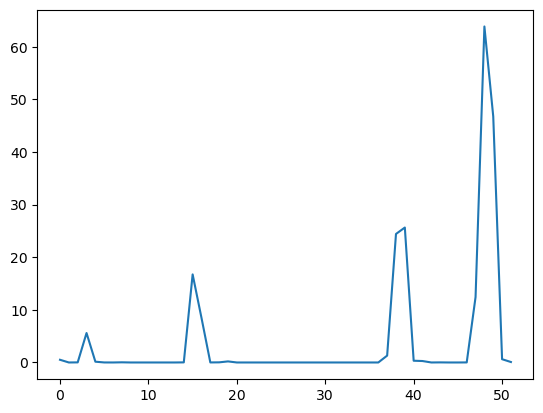

[ 0.00000611  0.00000346  0.00000421  0.00000346  0.82749194  3.3359325
 18.547323   40.153919    4.0670929   0.00429795  0.00017483  2.6997013
  0.29792616  0.00000344  0.00002553  0.00191231  0.01100953  0.01122039
  0.00392539  0.00000264  0.00000739  0.00000269  0.00000308  0.00000588
  0.0003329   0.00073728]
[ 0.82749194  3.3359325  18.547323   40.153919    4.0670929   0.00429795
  0.00017483  2.6997013   0.29792616]
------------


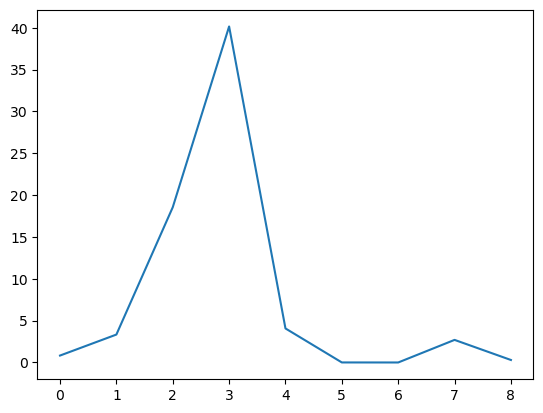

[ 0.00000569  0.00000275  0.01669136  5.7815609   5.5696073   4.3771529
 30.613047    1.3077806   3.7524211   0.06964263  0.0000027   0.00000383
  0.00000298  0.00000331  0.0000007   0.00000405  0.00000757  0.00000303
  0.00000225  0.00000317  0.00000431]
[ 5.7815609   5.5696073   4.3771529  30.613047    1.3077806   3.7524211
  0.06964263]
------------


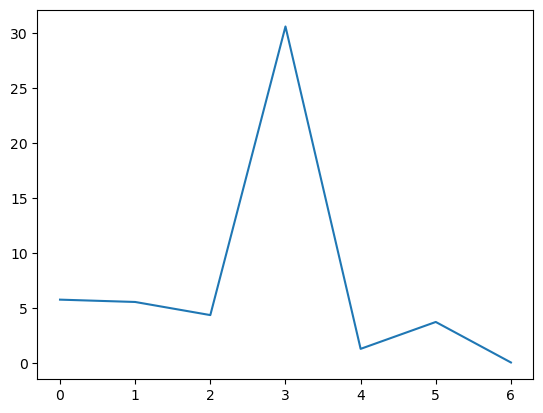

[ 0.01381266  0.000001    0.00000154  0.00000699  0.00000039  0.00000119
  0.00000105  0.00000117  0.00009577  0.46166328  0.5609712   0.00647403
  0.00000177  0.0000012   0.00000162  0.00000332  0.00000395  0.00000479
  0.00000365  0.00000113  0.00000137  0.00000079  0.00000068  0.00000099
  0.00000048 36.785984    8.9208593   2.5558112   0.20095707  0.00162833
  0.00000083  0.00000035  0.00000057  0.00000044  0.00000121  0.00000096
  0.0000023   0.00000332  0.00000151  0.00000124  0.50369418  1.7531637
  0.0000009   0.00000177  0.00000105  0.00000143  0.00000242  0.00000138]
[ 0.46166328  0.5609712   0.00647403  0.00000177  0.0000012   0.00000162
  0.00000332  0.00000395  0.00000479  0.00000365  0.00000113  0.00000137
  0.00000079  0.00000068  0.00000099  0.00000048 36.785984    8.9208593
  2.5558112   0.20095707  0.00162833  0.00000083  0.00000035  0.00000057
  0.00000044  0.00000121  0.00000096  0.0000023   0.00000332  0.00000151
  0.00000124  0.50369418  1.7531637 ]
------------


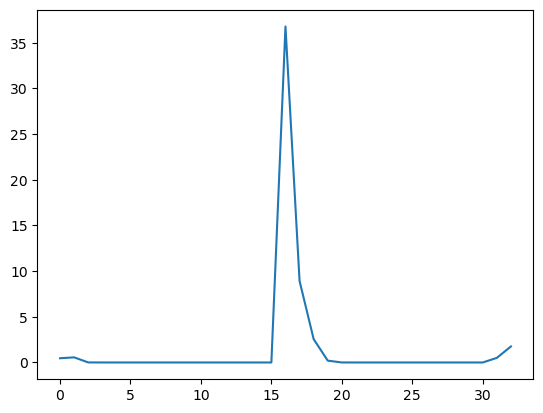

[ 0.          0.          0.          0.          0.00001285  0.00000095
  0.00004266  0.00003401  0.00000112  0.00000231  0.78631061  2.45305371
  0.00001376  0.00000089  0.47474736  0.33019388  0.1167855   1.01412177
  5.9328618   0.32430649  0.00000159  0.00000145  0.01675795  0.03204081
  0.41521031  0.06251699  0.10273434  0.00000684  3.69263816 44.3357849
 19.3877068   5.93022442  1.32772553  0.98151255  0.43672576  0.0744012
  3.34174633  0.64510131  2.4397676   2.26732683  1.11269271  2.05189157
  7.01200342  1.62119269  0.01846025  1.92257476  1.42880392  0.03251218
  0.00210331  0.00870181  0.00000085  0.169278    0.00000063  0.00000043
  0.00000167  0.00000076  0.00000045  0.00000035]
[ 0.78631061  2.45305371  0.00001376  0.00000089  0.47474736  0.33019388
  0.1167855   1.01412177  5.9328618   0.32430649  0.00000159  0.00000145
  0.01675795  0.03204081  0.41521031  0.06251699  0.10273434  0.00000684
  3.69263816 44.3357849  19.3877068   5.93022442  1.32772553  0.98151255
  0

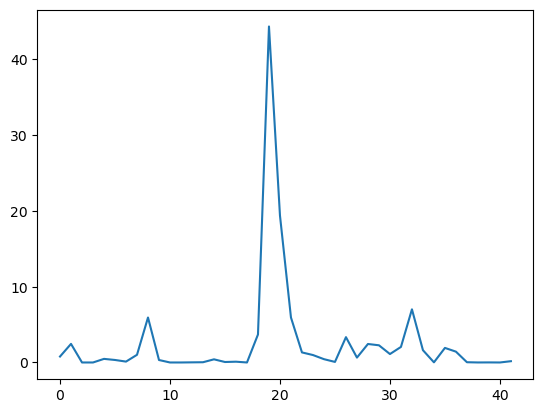

[ 0.          0.00000202  0.0173102   0.0288055   0.00002117  4.1415796
  7.5528274  42.190536    2.7798584   0.00304919  0.00000134  0.00000101
  0.00000097  0.00000025  0.00022621 19.541258    4.0941634   0.00014891
  0.00000156  0.00000115  0.00000057  0.00000033  0.00000531  0.00000581
  0.00000131  0.        ]
[ 4.1415796   7.5528274  42.190536    2.7798584   0.00304919  0.00000134
  0.00000101  0.00000097  0.00000025  0.00022621 19.541258    4.0941634 ]
------------


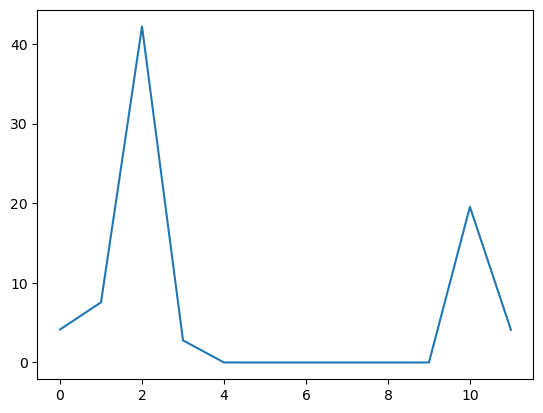

[ 0.00000386  0.57312727  2.0211365   1.643784    2.1758878   0.07462689
  0.00000084  0.0000025   0.0000028   0.00000256  0.0000023   0.00000147
  0.00000194  0.00000376  0.0122081  34.825401    7.3934827   2.2908642
  0.00000283  2.753154    0.49106729  2.7490709   2.0454307   0.0377189
  0.00000167  0.00000365  0.00000538  0.00000298  0.00000103  0.00000248
  0.00000711  0.00063475  0.00648258  0.00076581  0.0000057 ]
[ 0.57312727  2.0211365   1.643784    2.1758878   0.07462689  0.00000084
  0.0000025   0.0000028   0.00000256  0.0000023   0.00000147  0.00000194
  0.00000376  0.0122081  34.825401    7.3934827   2.2908642   0.00000283
  2.753154    0.49106729  2.7490709   2.0454307 ]
------------



KeyboardInterrupt



In [78]:
np.set_printoptions(suppress=True)
metrics = rainfall_events_all_df['values'].apply(compute_temporal_metrics)

In [70]:
metrics_df = pd.DataFrame(metrics.tolist(), index=rainfall_events_all_df.index)
metrics_df['length_of_active_rain'].min()

np.int64(7)

In [45]:
rainfall_events_all_df = pd.merge(rainfall_events_all_df, metrics_df, left_index=True, right_index=True)

In [54]:
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['length_of_active_rain']<100]
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['length_of_active_rain']>6]

(0.0, 150.0)

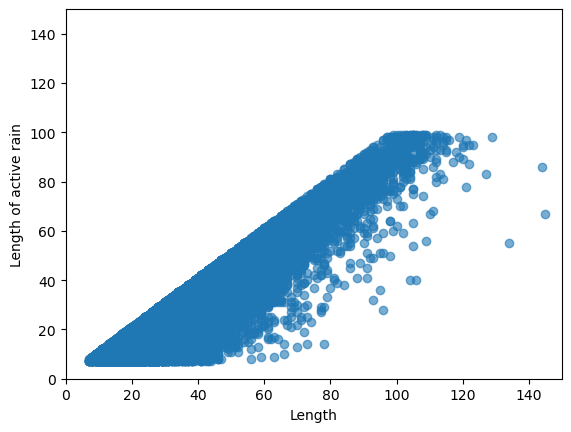

In [56]:
plt.scatter(rainfall_events_all_df[f'length'], rainfall_events_all_df[f'length_of_active_rain'], alpha = 0.6)
plt.xlabel('Length')
plt.ylabel('Length of active rain')
plt.xlim(0,150)
plt.ylim(0,150)

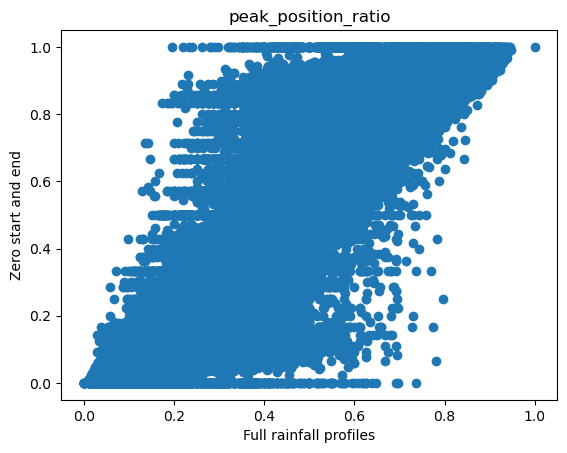

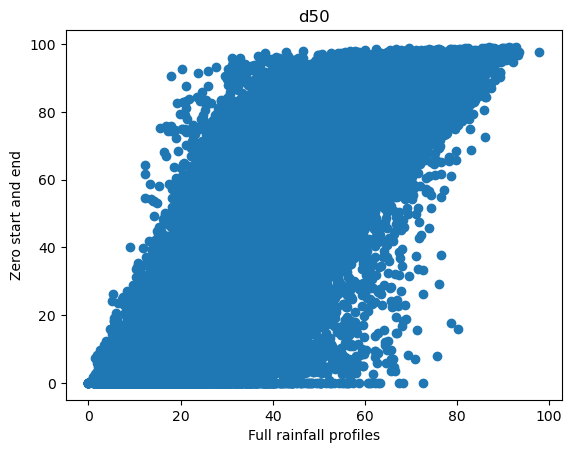

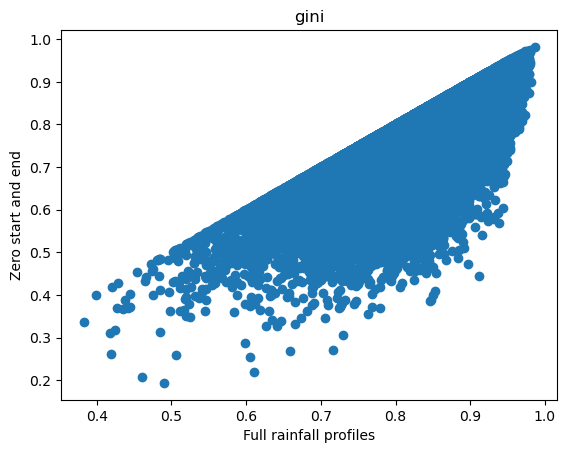

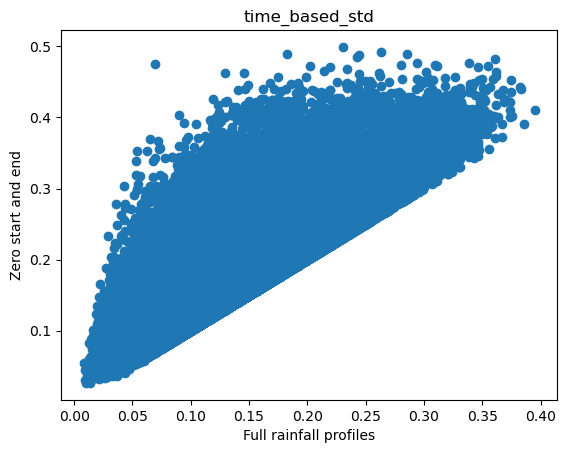

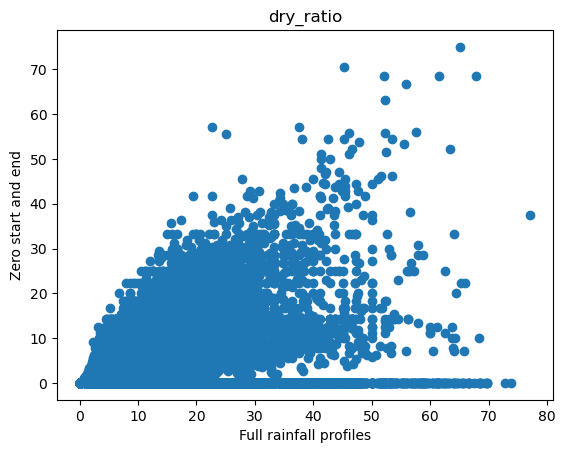

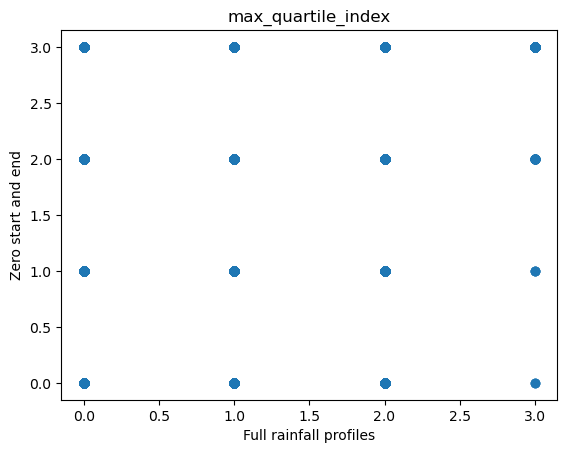

In [57]:
for variable in ["peak_position_ratio", "d50", "gini", "time_based_std", "dry_ratio", "max_quartile_index"]:
    plt.scatter(rainfall_events_all_df[f'{variable}'], rainfall_events_all_df[f'{variable}_n'])
    plt.title(variable)
    plt.xlabel('Full rainfall profiles')
    plt.ylabel('Zero start and end')
    plt.show()

### Save to file

In [58]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails_v4/all_catchments.pkl"
rainfall_events_all_df.to_pickle(fp)